# 🧬 Model Comparison — Cross-Validation & Test Summary
Compare all classifiers on the same pipeline.


Train: 455 | Test: 114


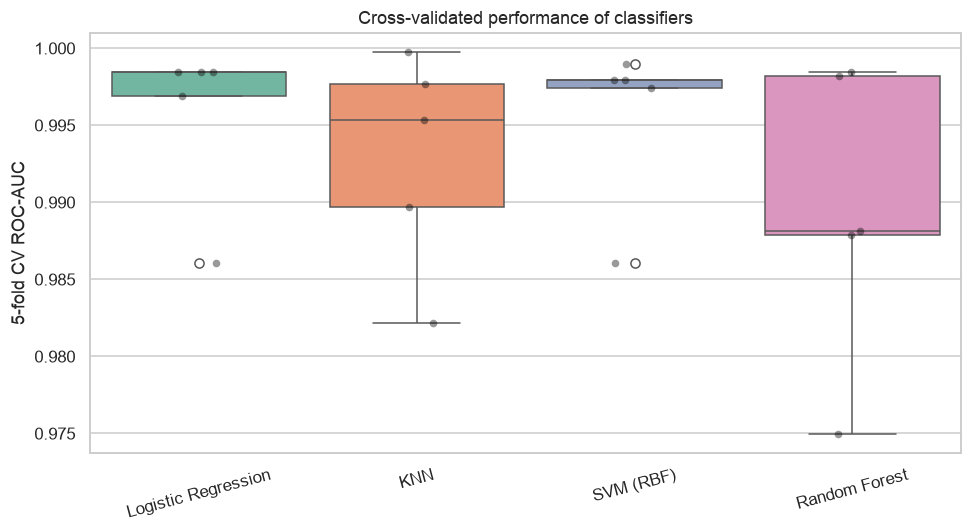

,accuracy,f1,roc_auc
model,,,
Logistic Regression,0.9825,0.9861,0.9954
SVM (RBF),0.9825,0.9861,0.9950
KNN,0.9737,0.9796,0.9944
Random Forest,0.9561,0.9655,0.9932


In [1]:
# ============================================================
# Setup
# ============================================================
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

# ============================================================
# Load data + preprocess (shared pipeline)
# ============================================================
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# ============================================================
# Compare all classifiers via 5-fold cross-validation
# ============================================================
cv = StratifiedKFold(5, shuffle=True, random_state=42)
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}
cv_results = {}
for name, m in models.items():
    cv_results[name] = cross_val_score(m, X_train_sc, y_train, cv=cv,
                                       scoring="roc_auc")

plt.figure(figsize=(9, 5))
sns.boxplot(data=pd.DataFrame(cv_results), palette="Set2")
sns.stripplot(data=pd.DataFrame(cv_results), color="black", alpha=0.4, jitter=True)
plt.ylabel("5-fold CV ROC-AUC")
plt.title("Cross-validated performance of classifiers")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

# ============================================================
# Summary table on the held-out test set
# ============================================================
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc
rows = []
for name, m in models.items():
    m.fit(X_train_sc, y_train)
    y_pred = m.predict(X_test_sc)
    y_prob = m.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    rows.append({"model": name,
                 "accuracy": accuracy_score(y_test, y_pred),
                 "f1": f1_score(y_test, y_pred),
                 "roc_auc": auc(fpr, tpr)})
results_df = pd.DataFrame(rows).set_index("model")
display(results_df.round(4).sort_values("f1", ascending=False))
